# Graphics creation

In [2]:
import pandas
import pathlib
import matplotlib.pyplot as plt

In [3]:
path = pathlib.Path(__name__).parent.resolve().joinpath('corrected', 'sabalenka_corrected.csv')

In [4]:
df = pandas.read_csv(path)

In [5]:
df2 = df.get(['surface', 'win_loss', 'score', 'bye', 'year', 'tour_code_alpha_3'])

In [6]:
win_loss_df = df2[~df2['win_loss'].isnull() & ~df2['surface'].isnull() & ~df2['bye']]

In [7]:
win_loss_df = win_loss_df[['surface', 'win_loss', 'year']]

## Win/Loss by Surface

In [8]:
wl_counts = win_loss_df.groupby(['surface', 'win_loss']).size().unstack(fill_value=0)
wl_counts

win_loss,L,W
surface,,
Carpet,1,6
Clay,53,109
Grass,22,43
Hard,130,362


<Figure size 1000x600 with 0 Axes>

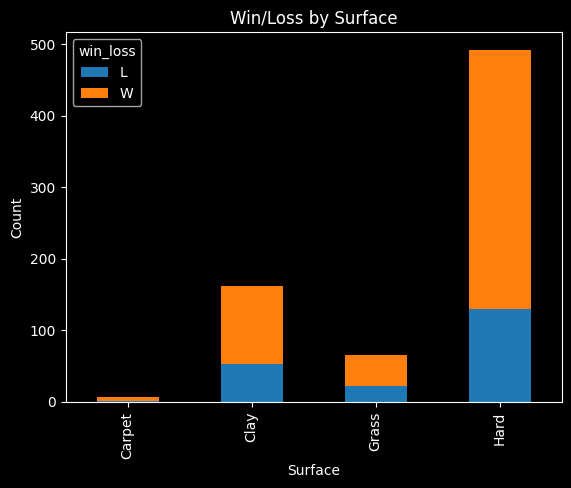

In [9]:
plt.figure(figsize=(10, 6))
wl_counts.plot(kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'])
plt.title('Win/Loss by Surface')
plt.xlabel('Surface')
plt.ylabel('Count')
plt.show()

## Win/Loss by Surface by Year

In [10]:
wl_by_surface_by_year = win_loss_df.groupby(['year', 'surface']).value_counts().unstack().fillna(0)
wl_by_surface_by_year

win_loss         L     W
year surface            
2012 Hard      1.0   0.0
2013 Hard      1.0   1.0
2014 Clay      2.0   2.0
     Hard      2.0   3.0
2015 Clay      6.0   4.0
     Hard      9.0  35.0
2016 Carpet    0.0   5.0
     Clay      6.0   6.0
     Hard     12.0  20.0
2017 Carpet    1.0   1.0
     Clay      4.0   2.0
     Grass     3.0   7.0
     Hard     17.0  27.0
2018 Clay      6.0   7.0
     Grass     4.0   7.0
     Hard     15.0  37.0
2019 Clay      5.0   5.0
     Grass     4.0   2.0
     Hard     13.0  32.0
2020 Clay      3.0   6.0
     Hard      7.0  23.0
2021 Clay      3.0  13.0
     Grass     3.0   7.0
     Hard     12.0  25.0
2022 Clay      5.0   9.0
     Grass     2.0   4.0
     Hard     15.0  20.0
2023 Clay      3.0  14.0
     Grass     2.0   6.0
     Hard      9.0  36.0
2024 Clay      4.0  15.0
     Grass     1.0   1.0
     Hard      9.0  40.0
2025 Clay      3.0  18.0
     Grass     2.0   7.0
     Hard      7.0  40.0
2026 Clay      3.0   8.0
     Grass     1.0   2.0
     Hard      1.0  23.0

In [17]:
df_wins = df[df['win_loss'] == 'W']
df_losses = df[df['win_loss'] == 'L']

wins_per_year = df_wins.groupby('year').size().reset_index(name='wins')
losses_per_year = df_losses.groupby('year').size().reset_index(name='losses')
merged = pandas.merge(wins_per_year, losses_per_year, on='year', how='outer').fillna(0)
merged.year.astype(str).tolist()
merged['wins'].astype(int).tolist()

[0, 1, 5, 39, 31, 37, 51, 39, 29, 45, 33, 56, 56, 65, 33]